In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif,chi2,mutual_info_classif


In [122]:
df=pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [124]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [125]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [126]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [127]:

df['Age']=df['Age'].fillna(df['Age'].median())
df['Cabin']=df['Cabin'].notna().replace({True:'cabin',False:'nocapin'})
# df['Cabin']=df['Cabin'].fillna('nocabin')
df['Embarked']=df['Embarked'].fillna('S')

In [128]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,nocapin,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,cabin,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,nocapin,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,cabin,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,nocapin,S


In [129]:
df.duplicated().sum()

np.int64(0)

In [130]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,nocapin,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,cabin,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,nocapin,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,cabin,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,nocapin,S


In [131]:
encoder=LabelEncoder()
df['gender']=encoder.fit_transform(df['Sex'])

In [132]:
df.drop(['PassengerId','Name','Ticket','Sex'],axis=1,inplace=True)

In [133]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Embarked,gender
0,0,3,22.0,1,0,7.2500,nocapin,S,1
1,1,1,38.0,1,0,71.2833,cabin,C,0
2,1,3,26.0,0,0,7.9250,nocapin,S,0
3,1,1,35.0,1,0,53.1000,cabin,S,0
4,0,3,35.0,0,0,8.0500,nocapin,S,1


In [134]:
df_encoded=pd.get_dummies(df,columns=['Embarked'])
df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,gender,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,nocapin,1,False,False,True
1,1,1,38.0,1,0,71.2833,cabin,0,True,False,False
2,1,3,26.0,0,0,7.9250,nocapin,0,False,False,True
3,1,1,35.0,1,0,53.1000,cabin,0,False,False,True
4,0,3,35.0,0,0,8.0500,nocapin,1,False,False,True


In [135]:
df['Cabin']=encoder.fit_transform(df['Cabin'])

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Embarked,gender
0,0,3,22.0,1,0,7.2500,1,S,1
1,1,1,38.0,1,0,71.2833,0,C,0
2,1,3,26.0,0,0,7.9250,1,S,0
3,1,1,35.0,1,0,53.1000,0,S,0
4,0,3,35.0,0,0,8.0500,1,S,1


In [136]:
df=pd.get_dummies(df,columns=['Embarked'],drop_first=True)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,gender,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,1,False,True
1,1,1,38.0,1,0,71.2833,0,0,False,False
2,1,3,26.0,0,0,7.9250,1,0,False,True
3,1,1,35.0,1,0,53.1000,0,0,False,True
4,0,3,35.0,0,0,8.0500,1,1,False,True


In [137]:
# df.loc[df['Cabin']!='no capin']='capin'

In [138]:
x=df.drop('Survived',axis=1)
y=df['Survived']

In [139]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

<Axes: >

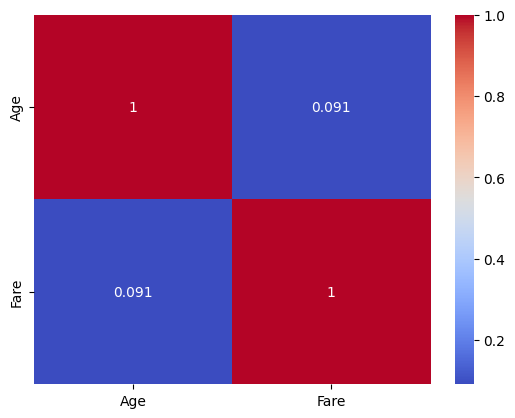

In [140]:
numerical=x_train[['Age','Fare']]
# numerical.corr(method='pearson') #for linear
numerical.corr(method='spearman') #for non linear
sns.heatmap(numerical.corr(method='pearson'),annot=True,cmap='coolwarm')

In [145]:
annova_scores,annova_pvalue=f_classif(numerical,y_train)
annova_results=pd.DataFrame({
    'feature':numerical.columns,
    'anove_score':annova_scores,
    'p_value':annova_pvalue
})
annova_results

,feature,anove_score,p_value
0,Age,1.680118,1.953299e-01
1,Fare,45.988025,2.506434e-11


In [146]:
annova_results.sort_values("p_value",ascending=False)

,feature,anove_score,p_value
0,Age,1.680118,1.953299e-01
1,Fare,45.988025,2.506434e-11


In [ ]:
x_train
y_train
x_train.head()

,Pclass,Age,SibSp,Parch,Fare,Cabin,gender,Embarked_Q,Embarked_S
331,1,45.5,0,0,28.5000,0,1,False,True
733,2,23.0,0,0,13.0000,1,1,False,True
382,3,32.0,0,0,7.9250,1,1,False,True
704,3,26.0,1,0,7.8542,1,1,False,True
813,3,6.0,4,2,31.2750,1,0,False,True
...,...,...,...,...,...,...,...,...,...
106,3,21.0,0,0,7.6500,1,0,False,True
270,1,28.0,0,0,31.0000,1,1,False,True
860,3,41.0,2,0,14.1083,1,1,False,True
435,1,14.0,1,2,120.0000,0,0,False,True


In [150]:
categ_col=x_train[['Pclass','Cabin','gender']]

In [152]:
chi_scores,p_v=chi2(categ_col,y_train)

In [153]:
chi_result=pd.DataFrame({
    'feature':categ_col.columns,
    'chi2_scores':chi_scores,
    'p_v':p_v
})
chi_result.sort_values('chi2_scores',ascending=False)

,feature,chi2_scores,p_v
2,gender,71.905882,2.257101e-17
0,Pclass,21.478863,3.577504e-06
1,Cabin,14.345399,1.521511e-04
